In [1]:
import pandas as pd

In [2]:
../

SyntaxError: invalid syntax (3509093073.py, line 1)

In [3]:
df_songs = pd.read_excel('../data/raw/Sony Music Publishing (SCORE)/SCORE_Song_Summary.xlsx', header = 7)

In [4]:
df_songs

,Song Title,Unnamed: 1,Client Royalty
0,+5,NaN,7.96
1,1 XANNY GEHT NOCH KLAR,NaN,2.26
2,??????,NaN,0.04
3,AGAIN,NaN,132.9
4,AMORE,NaN,83.87
...,...,...,...
112,WUSYANAME,NaN,157.47
113,ZOR DEIL,NaN,0.59
114,NaN,Domestic Earnings:,"34,450.04"
115,NaN,Foreign Earnings:,"7,357.58"


In [5]:
df_songs = df_songs.dropna(subset=['Song Title'])

In [6]:
df_songs

,Song Title,Unnamed: 1,Client Royalty
0,+5,NaN,7.96
1,1 XANNY GEHT NOCH KLAR,NaN,2.26
2,??????,NaN,0.04
3,AGAIN,NaN,132.9
4,AMORE,NaN,83.87
...,...,...,...
109,WHERE YOU BEEN AT,NaN,28.63
110,WHO IS MELO?,NaN,72.52
111,WTF I WANT,NaN,89.47
112,WUSYANAME,NaN,157.47


In [7]:
df_songs = df_songs.drop(columns=['Unnamed: 1'])

In [8]:
df_songs

,Song Title,Client Royalty
0,+5,7.96
1,1 XANNY GEHT NOCH KLAR,2.26
2,??????,0.04
3,AGAIN,132.9
4,AMORE,83.87
...,...,...
109,WHERE YOU BEEN AT,28.63
110,WHO IS MELO?,72.52
111,WTF I WANT,89.47
112,WUSYANAME,157.47


In [9]:
df_parties = pd.read_excel('../data/raw/Sony Music Publishing (SCORE)/SCORE_Song_Interested_Parties.xlsx', header = 5)

In [10]:
df_parties

,Song,Song Title,Writer(s)
0,6565950,+5,"Amiranovich Amiranovich(50%), Leonardo Bostan(..."
1,6547320,1 Xanny geht noch klar,"Kewin Rewers(50%), Leonardo Bostan(50%)"
2,5992541,2 Cocky,"Leonardo Bostan(50%), Luis Gaerdes(50%)"
3,6572314,??????,"Drugankin Ivan Dmitrievich(25%), Leonardo Bost..."
4,6588723,AMORE,"Elvis M(50%), Leonardo Bostan(50%)"
...,...,...,...
123,6207402,Za Smokin,"Angelo Turpin Jr(50%), Leonardo Bostan(50%)"
124,7172291,Zor Deil,"Alp Mutlu(16.60%), Emir Oztaskin(16.70%), Ferh..."
125,6602114,film,Leonardo Bostan(100%)
126,7019464,short & SWEET (feat. Baby Money & Payroll Giov...,"Carlos Deshawn Fischer(12.50%), Dior Giovanni ..."


In [11]:
df_songs['Song Title'] = df_songs['Song Title'].str.strip().str.upper()
df_parties['Song Title'] = df_parties['Song Title'].str.strip().str.upper()

In [12]:
df = pd.merge(df_songs, df_parties, on='Song Title', how='outer')

In [13]:
df

,Song Title,Client Royalty,Song,Writer(s)
0,+5,7.96,6565950,"Amiranovich Amiranovich(50%), Leonardo Bostan(..."
1,1 XANNY GEHT NOCH KLAR,2.26,6547320,"Kewin Rewers(50%), Leonardo Bostan(50%)"
2,2 COCKY,NaN,5992541,"Leonardo Bostan(50%), Luis Gaerdes(50%)"
3,??????,0.04,6572314,"Drugankin Ivan Dmitrievich(25%), Leonardo Bost..."
4,AGAIN,132.9,6537410,"Jairmy Long(50%), Leonardo Bostan(12.50%), Max..."
...,...,...,...,...
123,WHO IS MELO?,72.52,6547321,"Drugankin Ivan Dmitrievich(25%), Leonardo Bost..."
124,WTF I WANT,89.47,6972662,"Leonardo Bostan(12.50%), Martin Mccurtis(25%),..."
125,WUSYANAME,157.47,6685283,"Klayd Klayd(30%), Leonardo Bostan(70%)"
126,ZA SMOKIN,NaN,6207402,"Angelo Turpin Jr(50%), Leonardo Bostan(50%)"


In [14]:
df = df.rename(columns={'Song': 'song_id', 'Song Title': 'song_title', 'Client Royalty': 'my_earnings_usd', 'Writer(s)': 'writers'})

In [15]:
df

,song_title,my_earnings_usd,song_id,writers
0,+5,7.96,6565950,"Amiranovich Amiranovich(50%), Leonardo Bostan(..."
1,1 XANNY GEHT NOCH KLAR,2.26,6547320,"Kewin Rewers(50%), Leonardo Bostan(50%)"
2,2 COCKY,NaN,5992541,"Leonardo Bostan(50%), Luis Gaerdes(50%)"
3,??????,0.04,6572314,"Drugankin Ivan Dmitrievich(25%), Leonardo Bost..."
4,AGAIN,132.9,6537410,"Jairmy Long(50%), Leonardo Bostan(12.50%), Max..."
...,...,...,...,...
123,WHO IS MELO?,72.52,6547321,"Drugankin Ivan Dmitrievich(25%), Leonardo Bost..."
124,WTF I WANT,89.47,6972662,"Leonardo Bostan(12.50%), Martin Mccurtis(25%),..."
125,WUSYANAME,157.47,6685283,"Klayd Klayd(30%), Leonardo Bostan(70%)"
126,ZA SMOKIN,NaN,6207402,"Angelo Turpin Jr(50%), Leonardo Bostan(50%)"


In [16]:
df['my_earnings_usd'] = df['my_earnings_usd'].fillna(0.00)

/var/folders/bd/pl944hbj61n6mpghlwvnxy5r0000gn/T/ipykernel_6501/2499682987.py:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['my_earnings_usd'] = df['my_earnings_usd'].fillna(0.00)


In [17]:
df

,song_title,my_earnings_usd,song_id,writers
0,+5,7.96,6565950,"Amiranovich Amiranovich(50%), Leonardo Bostan(..."
1,1 XANNY GEHT NOCH KLAR,2.26,6547320,"Kewin Rewers(50%), Leonardo Bostan(50%)"
2,2 COCKY,0.00,5992541,"Leonardo Bostan(50%), Luis Gaerdes(50%)"
3,??????,0.04,6572314,"Drugankin Ivan Dmitrievich(25%), Leonardo Bost..."
4,AGAIN,132.90,6537410,"Jairmy Long(50%), Leonardo Bostan(12.50%), Max..."
...,...,...,...,...
123,WHO IS MELO?,72.52,6547321,"Drugankin Ivan Dmitrievich(25%), Leonardo Bost..."
124,WTF I WANT,89.47,6972662,"Leonardo Bostan(12.50%), Martin Mccurtis(25%),..."
125,WUSYANAME,157.47,6685283,"Klayd Klayd(30%), Leonardo Bostan(70%)"
126,ZA SMOKIN,0.00,6207402,"Angelo Turpin Jr(50%), Leonardo Bostan(50%)"


In [18]:
import re

def extract_my_share(writers_string):
    match = re.search(r'Leonardo Bostan\((\d+\.?\d*)%\)', str(writers_string))
    if match:
        return float(match.group(1))
    return None

def extract_n_collaborators(writers_string):
    return str(writers_string).count('(')

In [19]:
df['my_share_pct'] = df['writers'].apply(extract_my_share)

In [20]:
df

,song_title,my_earnings_usd,song_id,writers,my_share_pct
0,+5,7.96,6565950,"Amiranovich Amiranovich(50%), Leonardo Bostan(...",50.0
1,1 XANNY GEHT NOCH KLAR,2.26,6547320,"Kewin Rewers(50%), Leonardo Bostan(50%)",50.0
2,2 COCKY,0.00,5992541,"Leonardo Bostan(50%), Luis Gaerdes(50%)",50.0
3,??????,0.04,6572314,"Drugankin Ivan Dmitrievich(25%), Leonardo Bost...",25.0
4,AGAIN,132.90,6537410,"Jairmy Long(50%), Leonardo Bostan(12.50%), Max...",12.5
...,...,...,...,...,...
123,WHO IS MELO?,72.52,6547321,"Drugankin Ivan Dmitrievich(25%), Leonardo Bost...",25.0
124,WTF I WANT,89.47,6972662,"Leonardo Bostan(12.50%), Martin Mccurtis(25%),...",12.5
125,WUSYANAME,157.47,6685283,"Klayd Klayd(30%), Leonardo Bostan(70%)",70.0
126,ZA SMOKIN,0.00,6207402,"Angelo Turpin Jr(50%), Leonardo Bostan(50%)",50.0


In [21]:
df['collaboratos_count'] = df['writers'].apply(extract_n_collaborators)

In [22]:
df

,song_title,my_earnings_usd,song_id,writers,my_share_pct,collaboratos_count
0,+5,7.96,6565950,"Amiranovich Amiranovich(50%), Leonardo Bostan(...",50.0,2
1,1 XANNY GEHT NOCH KLAR,2.26,6547320,"Kewin Rewers(50%), Leonardo Bostan(50%)",50.0,2
2,2 COCKY,0.00,5992541,"Leonardo Bostan(50%), Luis Gaerdes(50%)",50.0,2
3,??????,0.04,6572314,"Drugankin Ivan Dmitrievich(25%), Leonardo Bost...",25.0,3
4,AGAIN,132.90,6537410,"Jairmy Long(50%), Leonardo Bostan(12.50%), Max...",12.5,4
...,...,...,...,...,...,...
123,WHO IS MELO?,72.52,6547321,"Drugankin Ivan Dmitrievich(25%), Leonardo Bost...",25.0,3
124,WTF I WANT,89.47,6972662,"Leonardo Bostan(12.50%), Martin Mccurtis(25%),...",12.5,4
125,WUSYANAME,157.47,6685283,"Klayd Klayd(30%), Leonardo Bostan(70%)",70.0,2
126,ZA SMOKIN,0.00,6207402,"Angelo Turpin Jr(50%), Leonardo Bostan(50%)",50.0,2


In [23]:
df = df.rename(columns={'collaboratos_count': 'collaborators_count'})

In [24]:
df

,song_title,my_earnings_usd,song_id,writers,my_share_pct,collaborators_count
0,+5,7.96,6565950,"Amiranovich Amiranovich(50%), Leonardo Bostan(...",50.0,2
1,1 XANNY GEHT NOCH KLAR,2.26,6547320,"Kewin Rewers(50%), Leonardo Bostan(50%)",50.0,2
2,2 COCKY,0.00,5992541,"Leonardo Bostan(50%), Luis Gaerdes(50%)",50.0,2
3,??????,0.04,6572314,"Drugankin Ivan Dmitrievich(25%), Leonardo Bost...",25.0,3
4,AGAIN,132.90,6537410,"Jairmy Long(50%), Leonardo Bostan(12.50%), Max...",12.5,4
...,...,...,...,...,...,...
123,WHO IS MELO?,72.52,6547321,"Drugankin Ivan Dmitrievich(25%), Leonardo Bost...",25.0,3
124,WTF I WANT,89.47,6972662,"Leonardo Bostan(12.50%), Martin Mccurtis(25%),...",12.5,4
125,WUSYANAME,157.47,6685283,"Klayd Klayd(30%), Leonardo Bostan(70%)",70.0,2
126,ZA SMOKIN,0.00,6207402,"Angelo Turpin Jr(50%), Leonardo Bostan(50%)",50.0,2


In [25]:
df['my_share_pct'].isna().sum()

np.int64(0)

In [26]:
df['true_song_size'] = df['my_earnings_usd'] / (df['my_share_pct'] / 100)

In [27]:
df

,song_title,my_earnings_usd,song_id,writers,my_share_pct,collaborators_count,true_song_size
0,+5,7.96,6565950,"Amiranovich Amiranovich(50%), Leonardo Bostan(...",50.0,2,15.920000
1,1 XANNY GEHT NOCH KLAR,2.26,6547320,"Kewin Rewers(50%), Leonardo Bostan(50%)",50.0,2,4.520000
2,2 COCKY,0.00,5992541,"Leonardo Bostan(50%), Luis Gaerdes(50%)",50.0,2,0.000000
3,??????,0.04,6572314,"Drugankin Ivan Dmitrievich(25%), Leonardo Bost...",25.0,3,0.160000
4,AGAIN,132.90,6537410,"Jairmy Long(50%), Leonardo Bostan(12.50%), Max...",12.5,4,1063.200000
...,...,...,...,...,...,...,...
123,WHO IS MELO?,72.52,6547321,"Drugankin Ivan Dmitrievich(25%), Leonardo Bost...",25.0,3,290.080000
124,WTF I WANT,89.47,6972662,"Leonardo Bostan(12.50%), Martin Mccurtis(25%),...",12.5,4,715.760000
125,WUSYANAME,157.47,6685283,"Klayd Klayd(30%), Leonardo Bostan(70%)",70.0,2,224.957143
126,ZA SMOKIN,0.00,6207402,"Angelo Turpin Jr(50%), Leonardo Bostan(50%)",50.0,2,0.000000


In [28]:
pd.set_option('display.float_format', '{:.2f}'.format)

In [29]:
df

,song_title,my_earnings_usd,song_id,writers,my_share_pct,collaborators_count,true_song_size
0,+5,7.96,6565950,"Amiranovich Amiranovich(50%), Leonardo Bostan(...",50.00,2,15.92
1,1 XANNY GEHT NOCH KLAR,2.26,6547320,"Kewin Rewers(50%), Leonardo Bostan(50%)",50.00,2,4.52
2,2 COCKY,0.00,5992541,"Leonardo Bostan(50%), Luis Gaerdes(50%)",50.00,2,0.00
3,??????,0.04,6572314,"Drugankin Ivan Dmitrievich(25%), Leonardo Bost...",25.00,3,0.16
4,AGAIN,132.90,6537410,"Jairmy Long(50%), Leonardo Bostan(12.50%), Max...",12.50,4,1063.20
...,...,...,...,...,...,...,...
123,WHO IS MELO?,72.52,6547321,"Drugankin Ivan Dmitrievich(25%), Leonardo Bost...",25.00,3,290.08
124,WTF I WANT,89.47,6972662,"Leonardo Bostan(12.50%), Martin Mccurtis(25%),...",12.50,4,715.76
125,WUSYANAME,157.47,6685283,"Klayd Klayd(30%), Leonardo Bostan(70%)",70.00,2,224.96
126,ZA SMOKIN,0.00,6207402,"Angelo Turpin Jr(50%), Leonardo Bostan(50%)",50.00,2,0.00


In [30]:
median_true_song_size = df['true_song_size'].median()

In [31]:
median_true_song_size

np.float64(97.63)

In [32]:
df['is_large_song'] = df['true_song_size'] > median_true_song_size

In [33]:
df

,song_title,my_earnings_usd,song_id,writers,my_share_pct,collaborators_count,true_song_size,is_large_song
0,+5,7.96,6565950,"Amiranovich Amiranovich(50%), Leonardo Bostan(...",50.00,2,15.92,False
1,1 XANNY GEHT NOCH KLAR,2.26,6547320,"Kewin Rewers(50%), Leonardo Bostan(50%)",50.00,2,4.52,False
2,2 COCKY,0.00,5992541,"Leonardo Bostan(50%), Luis Gaerdes(50%)",50.00,2,0.00,False
3,??????,0.04,6572314,"Drugankin Ivan Dmitrievich(25%), Leonardo Bost...",25.00,3,0.16,False
4,AGAIN,132.90,6537410,"Jairmy Long(50%), Leonardo Bostan(12.50%), Max...",12.50,4,1063.20,True
...,...,...,...,...,...,...,...,...
123,WHO IS MELO?,72.52,6547321,"Drugankin Ivan Dmitrievich(25%), Leonardo Bost...",25.00,3,290.08,True
124,WTF I WANT,89.47,6972662,"Leonardo Bostan(12.50%), Martin Mccurtis(25%),...",12.50,4,715.76,True
125,WUSYANAME,157.47,6685283,"Klayd Klayd(30%), Leonardo Bostan(70%)",70.00,2,224.96,True
126,ZA SMOKIN,0.00,6207402,"Angelo Turpin Jr(50%), Leonardo Bostan(50%)",50.00,2,0.00,False


In [34]:
df['my_earnings_usd'].sum()

np.float64(41807.62000000001)

In [35]:
df['is_large_song'].value.counts()

AttributeError: 'Series' object has no attribute 'value'

In [36]:
df['is_large_song'].value_counts()

is_large_song
False    64
True     64
Name: count, dtype: int64

In [37]:
df.to_csv('.../data/processed/analysis_ready.csv',index=False)

OSError: Cannot save file into a non-existent directory: '.../data/processed'

In [37]:
df.to_csv('.../data/processed/analysis_ready.csv',index=False)

OSError: Cannot save file into a non-existent directory: '.../data/processed'

In [38]:
df.to_csv('../data/processed/analysis_ready.csv',index=False)

In [39]:
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


In [40]:
avg_earnings = df.groupby('is_large_song')['my_earnings_usd'].mean()

In [41]:
avg_earnings

is_large_song
False     5.13
True    648.11
Name: my_earnings_usd, dtype: float64

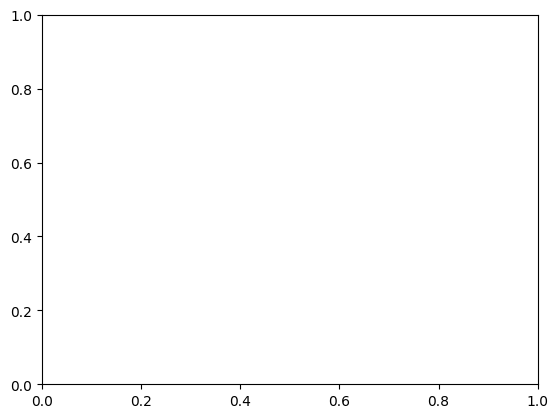

In [42]:
fig, ax = plt.subplots()

In [43]:
ax.bar = (['Kleiner Song', 'Großer Song'], avg_earnings_values)

NameError: name 'avg_earnings_values' is not defined

In [44]:
ax.bar = (['Kleiner Song', 'Großer Song'], avg_earnings.values)

In [45]:
plt.show()

In [46]:
ax.set_yLabel('Durchschnittliche Einnahmen in USD')

AttributeError: 'Axes' object has no attribute 'set_yLabel'

In [47]:
ax.set_ylabel('Durchschnittliche Einnahmen in USD')

Text(4.444444444444445, 0.5, 'Durchschnittliche Einnahmen in USD')

In [48]:
ax.set_title('Durchschnittliche Einnahmen: Großer vs. Kleiner Song')

Text(0.5, 1.0, 'Durchschnittliche Einnahmen: Großer vs. Kleiner Song')

In [49]:
plt.savefig('../figures/avg_earnings_by_size.png', dpi=150, bbox_inches = 'tight')

<Figure size 640x480 with 0 Axes>

In [50]:
plt.show()

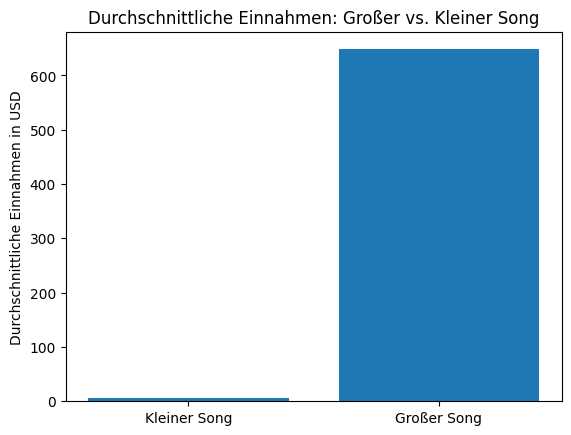

In [51]:
fig, ax = plt.subplots()
ax.bar(['Kleiner Song', 'Großer Song'], avg_earnings.values)
ax.set_ylabel('Durchschnittliche Einnahmen in USD')
ax.set_title('Durchschnittliche Einnahmen: Großer vs. Kleiner Song')
plt.savefig('../figures/avg_earnings_by_size.png', dpi = 150, bbox_inches = 'tight')
plt.show()

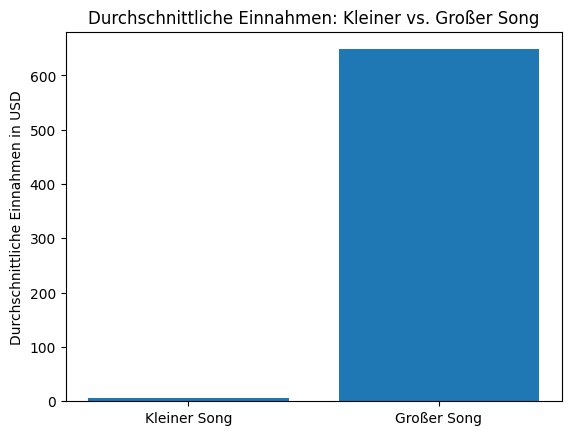

In [52]:
fig, ax = plt.subplots()
ax.bar(['Kleiner Song', 'Großer Song'], avg_earnings.values)
ax.set_ylabel('Durchschnittliche Einnahmen in USD')
ax.set_title('Durchschnittliche Einnahmen: Kleiner vs. Großer Song')
plt.savefig('../figures/avg_earnings_by_size.png', dpi = 150, bbox_inches = 'tight')
plt.show()

In [53]:
bars = ax.bar(['Kleiner Song', 'Großer Song'], avg_earnings.values)

In [54]:
ax.bar_label(bars)

[Text(0, 0, '5.13344'), Text(0, 0, '648.111')]

In [55]:
plt.show()

In [56]:
ax.bar_label(bars, fmt = '%.2f')

[Text(0, 0, '5.13'), Text(0, 0, '648.11')]

In [57]:
bars = ax.bar(['Kleiner Song', 'Großer Song'], avg_earnings.values, color=['blue', 'orange'])

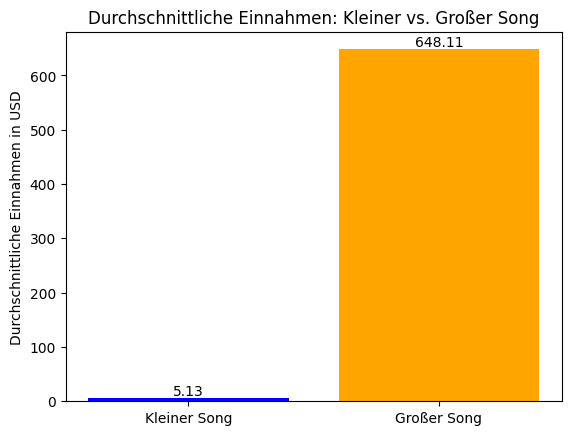

In [58]:
fig, ax = plt.subplots()
bars = ax.bar(['Kleiner Song', 'Großer Song'], avg_earnings.values, color=['blue', 'orange'])
ax.bar_label(bars, fmt = '%.2f')
ax.set_ylabel('Durchschnittliche Einnahmen in USD')
ax.set_title('Durchschnittliche Einnahmen: Kleiner vs. Großer Song')
plt.savefig('../figures/avg_earnings_by_size.png', dpi = 150, bbox_inches = 'tight')
plt.show()

In [59]:
df_sorted = df.sort_values('my_earnings_usd', ascending=False)

In [60]:
df_sorted['my_earnings_usd'].head(10)

40    7356.79
104   5160.13
112   4501.24
33    2267.41
75    1984.01
36    1584.66
92    1209.67
109   1138.54
77     954.36
100    772.02
Name: my_earnings_usd, dtype: float64

In [61]:
cumulativ = df_sorted['my_earnings_usd'].cumsum() / df_sorted['my_earnings_usd].sum()

SyntaxError: EOL while scanning string literal (828845819.py, line 1)

In [62]:
cumulativ = df_sorted['my_earnings_usd'].cumsum() / df_sorted['my_earnings_usd'].sum()

In [63]:
cumulativ

40    0.18
104   0.30
112   0.41
33    0.46
75    0.51
      ... 
108   1.00
103   1.00
70    1.00
81    1.00
64    1.00
Name: my_earnings_usd, Length: 128, dtype: float64

In [64]:
cumulativ.head(10)

40    0.18
104   0.30
112   0.41
33    0.46
75    0.51
36    0.55
92    0.58
109   0.60
77    0.63
100   0.64
Name: my_earnings_usd, dtype: float64

In [65]:
x = range(1, len(df_sorted) + 1)
x_pct = [i / len(df_sorted) * 100 for i in x]

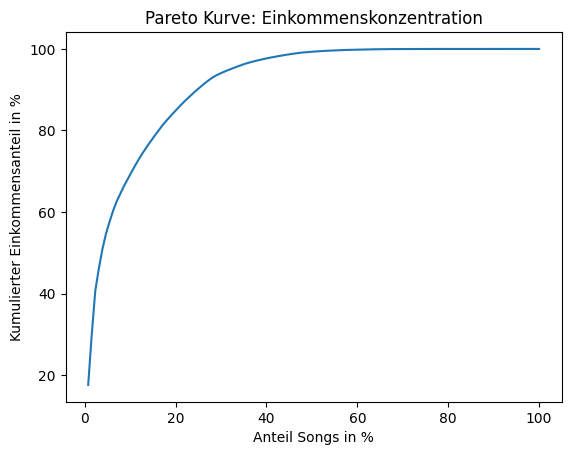

In [66]:
fig, ax = plt.subplots()
ax.plot(x_pct, cumulativ.values * 100)
ax.set_xlabel('Anteil Songs in %')
ax.set_ylabel('Kumulierter Einkommensanteil in %')
ax.set_title('Pareto Kurve: Einkommenskonzentration')
plt.savefig('../figures/pareto_curve.png', dpi = 150, bbox_inches = 'tight')
plt.show()

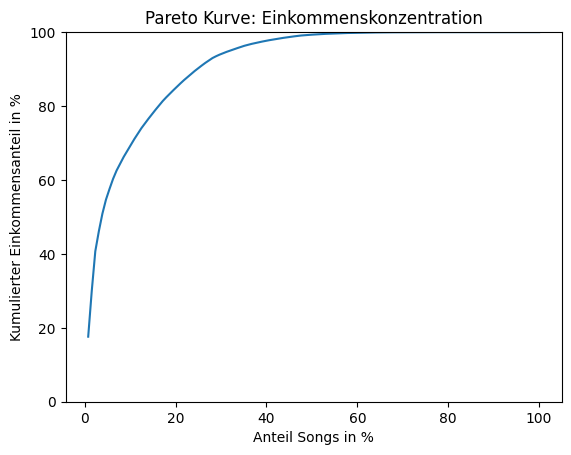

In [67]:
fig, ax = plt.subplots()
ax.plot(x_pct, cumulativ.values * 100)
ax.set_xlabel('Anteil Songs in %')
ax.set_ylabel('Kumulierter Einkommensanteil in %')
ax.set_title('Pareto Kurve: Einkommenskonzentration')
ax.set_ylim(0, 100)
plt.savefig('../figures/pareto_curve.png', dpi = 150, bbox_inches = 'tight')
plt.show()

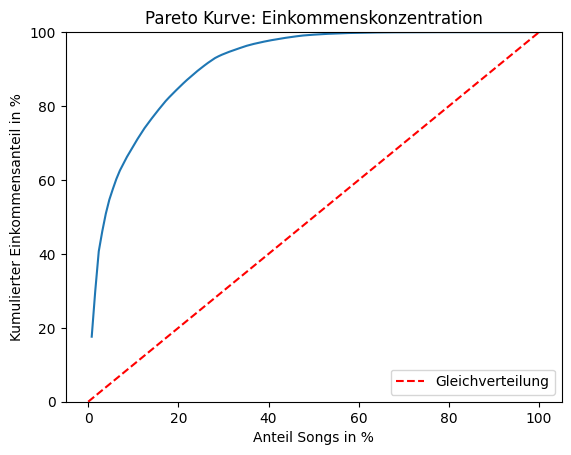

In [68]:
fig, ax = plt.subplots()
ax.plot(x_pct, cumulativ.values * 100)
ax.set_xlabel('Anteil Songs in %')
ax.set_ylabel('Kumulierter Einkommensanteil in %')
ax.set_title('Pareto Kurve: Einkommenskonzentration')
ax.set_ylim(0, 100)
ax.plot([0, 100], [0, 100], 'r--', label='Gleichverteilung')
ax.legend()
plt.savefig('../figures/pareto_curve.png', dpi = 150, bbox_inches = 'tight')
plt.show()

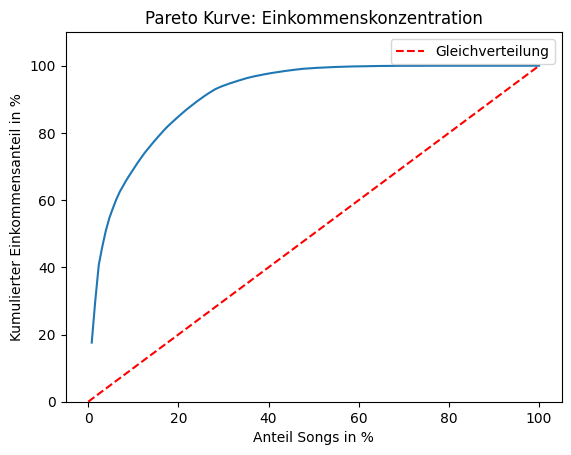

In [69]:
fig, ax = plt.subplots()
ax.plot(x_pct, cumulativ.values * 100)
ax.set_xlabel('Anteil Songs in %')
ax.set_ylabel('Kumulierter Einkommensanteil in %')
ax.set_title('Pareto Kurve: Einkommenskonzentration')
ax.set_ylim(0, 110)
ax.plot([0, 100], [0, 100], 'r--', label='Gleichverteilung')
ax.legend()
plt.savefig('../figures/pareto_curve.png', dpi = 150, bbox_inches = 'tight')
plt.show()

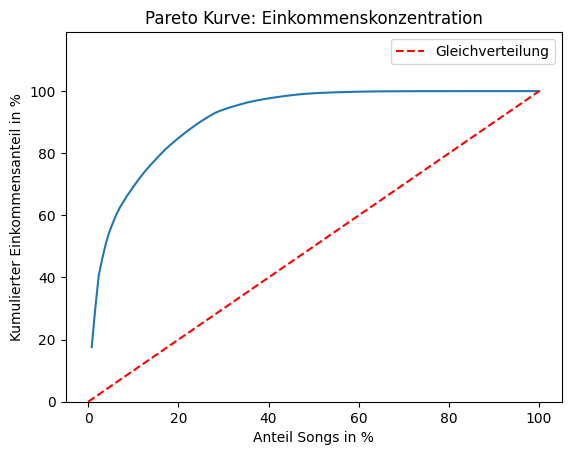

In [70]:
fig, ax = plt.subplots()
ax.plot(x_pct, cumulativ.values * 100)
ax.set_xlabel('Anteil Songs in %')
ax.set_ylabel('Kumulierter Einkommensanteil in %')
ax.set_title('Pareto Kurve: Einkommenskonzentration')
ax.set_ylim(0, 119)
ax.plot([0, 100], [0, 100], 'r--', label='Gleichverteilung')
ax.legend()
plt.savefig('../figures/pareto_curve.png', dpi = 150, bbox_inches = 'tight')
plt.show()

NameError: name 'cumulative' is not defined

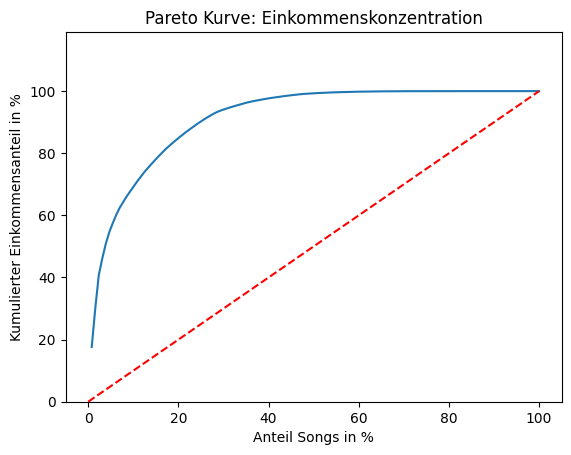

In [71]:
fig, ax = plt.subplots()
ax.plot(x_pct, cumulativ.values * 100)
ax.set_xlabel('Anteil Songs in %')
ax.set_ylabel('Kumulierter Einkommensanteil in %')
ax.set_title('Pareto Kurve: Einkommenskonzentration')
ax.set_ylim(0, 119)
ax.plot([0, 100], [0, 100], 'r--', label='Gleichverteilung')
ax.plot(x_pct, cumulative.values * 100, label='Tatsächliche Verteilung')
ax.legend()
plt.savefig('../figures/pareto_curve.png', dpi = 150, bbox_inches = 'tight')
plt.show()

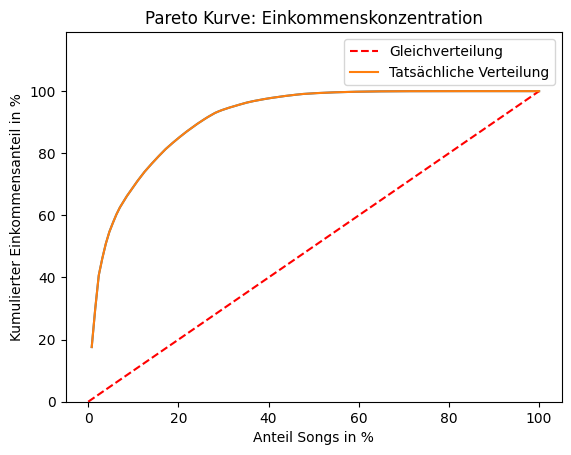

In [72]:
fig, ax = plt.subplots()
ax.plot(x_pct, cumulativ.values * 100)
ax.set_xlabel('Anteil Songs in %')
ax.set_ylabel('Kumulierter Einkommensanteil in %')
ax.set_title('Pareto Kurve: Einkommenskonzentration')
ax.set_ylim(0, 119)
ax.plot([0, 100], [0, 100], 'r--', label='Gleichverteilung')
ax.plot(x_pct, cumulativ.values * 100, label='Tatsächliche Verteilung')
ax.legend()
plt.savefig('../figures/pareto_curve.png', dpi = 150, bbox_inches = 'tight')
plt.show()

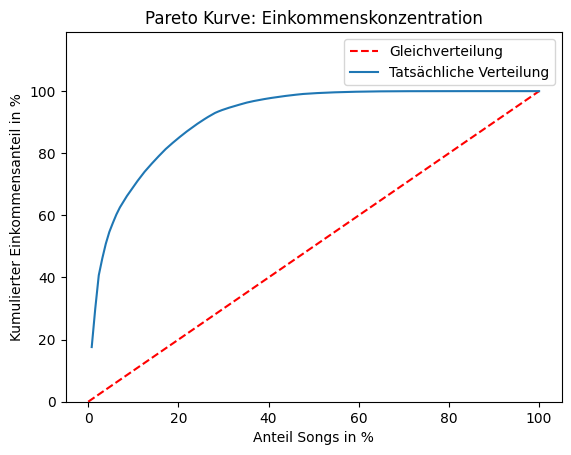

In [73]:
fig, ax = plt.subplots()
ax.set_xlabel('Anteil Songs in %')
ax.set_ylabel('Kumulierter Einkommensanteil in %')
ax.set_title('Pareto Kurve: Einkommenskonzentration')
ax.set_ylim(0, 119)
ax.plot([0, 100], [0, 100], 'r--', label='Gleichverteilung')
ax.plot(x_pct, cumulativ.values * 100, label='Tatsächliche Verteilung')
ax.legend()
plt.savefig('../figures/pareto_curve.png', dpi = 150, bbox_inches = 'tight')
plt.show()

In [74]:
top_25 = df[df['my_earnings_usd'] >= df['my_earnings_usd'].quantile(0.75)]

In [75]:
bottom_23 = df[df['my_earnings_usd'] >= df['my_earnings_usd'].quantile(0.25)]

In [76]:
bottom_25 = df[df['my_earnings_usd'] >= df['my_earnings_usd'].quantile(0.25)]

In [77]:
print(len(top_25), len(bottom_25))

32 96


In [78]:
df['my_earnings_usd'].quantile(0.25)

np.float64(0.5725)

In [79]:
top_32 = df.nlargest(32, 'my_earnings_usd')

In [80]:
top_32 = df.nsmallest(32, 'my_earnings_usd')

In [81]:
top_32 = df.nlargest(32, 'my_earnings_usd')

In [82]:
bottom_32 = df.nsmallest(32, 'my_earnings_usd')

In [83]:
print(len(top_32), len(bottom_32))

32 32


In [84]:
print('Top 32:')
print('Durchschnittlicher Anteil %:', top_32['my_share_pct'].mean().round(1))
print('Durchschnittliche Kollaborateure:', top_32['collaborators_count'].mean().round(1))

print('Bottom 32:')
print('Durchschnittlicher Anteil %:', bottom_32['my_share_pct'].mean().round(1))
print('Durchschnittliche Kollaborateure:', bottom_32['collaborators_count'].mean().round(1))

Top 32:
Durchschnittlicher Anteil %: 48.6
Durchschnittliche Kollaborateure: 2.6
Bottom 32:
Durchschnittlicher Anteil %: 44.6
Durchschnittliche Kollaborateure: 2.4


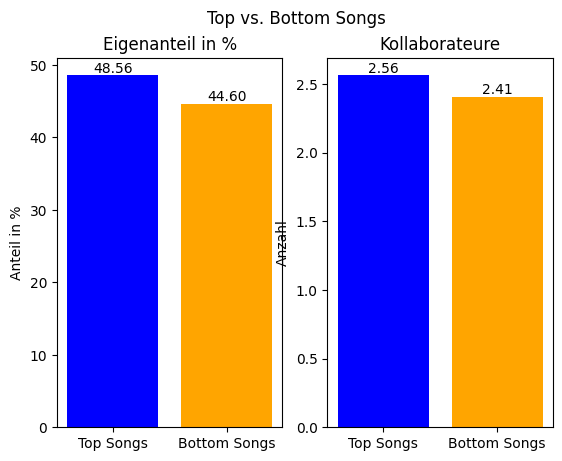

In [85]:
fig, (ax1, ax2) = plt.subplots(1, 2)
bars1 = ax1.bar(['Top Songs', 'Bottom Songs'], [top_32['my_share_pct'].mean(), bottom_32['my_share_pct'].mean()], color=['blue', 'orange'])
bars2 = ax2.bar(['Top Songs', 'Bottom Songs'], [top_32['collaborators_count'].mean(), bottom_32['collaborators_count'].mean()], color=['blue', 'orange'])
ax1.bar_label(bars1, fmt = '%.2f')
ax2.bar_label(bars2, fmt = '%.2f')
ax1.set_ylabel('Anteil in %')
ax2.set_ylabel('Anzahl')
ax1.set_title('Eigenanteil in %')
ax2.set_title('Kollaborateure')
fig.suptitle('Top vs. Bottom Songs')
plt.savefig('../figures/top_bottom_songs.png', dpi = 150, bbox_inches = 'tight')
plt.show()

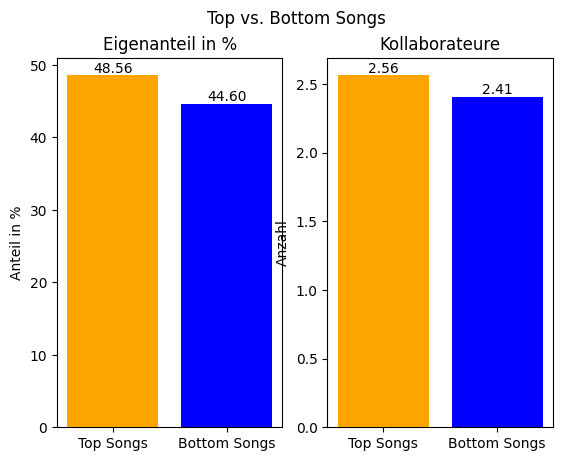

In [86]:
fig, (ax1, ax2) = plt.subplots(1, 2)
bars1 = ax1.bar(['Top Songs', 'Bottom Songs'], [top_32['my_share_pct'].mean(), bottom_32['my_share_pct'].mean()], color=['orange', 'blue'])
bars2 = ax2.bar(['Top Songs', 'Bottom Songs'], [top_32['collaborators_count'].mean(), bottom_32['collaborators_count'].mean()], color=['orange', 'blue'])
ax1.bar_label(bars1, fmt = '%.2f')
ax2.bar_label(bars2, fmt = '%.2f')
ax1.set_ylabel('Anteil in %')
ax2.set_ylabel('Anzahl')
ax1.set_title('Eigenanteil in %')
ax2.set_title('Kollaborateure')
fig.suptitle('Top vs. Bottom Songs')
plt.savefig('../figures/top_bottom_songs.png', dpi = 150, bbox_inches = 'tight')
plt.show()